# Лабораторная работа 5. Ансамбли моделей машинного обучения. Часть 1

**Цель работы:** изучение ансамблей моделей машинного обучения.

**Задание:**
1. Выбрать набор данных для задачи классификации или регрессии.
2. При необходимости провести удаление/заполнение пропусков и кодирование категориальных признаков.
3. С помощью `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить ансамблевые модели:
   - две модели группы бэггинга (бэггинг / случайный лес / сверхслучайные деревья);
   - `AdaBoost`;
   - градиентный бустинг.
5. Оценить качество моделей подходящей метрикой и сравнить результаты.

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Выбор датасета и загрузка данных

Используем датасет `StudentsPerformance.csv` (тот же, что и в ЛР № 4 — это позволяет напрямую сравнить ансамбли с одиночными моделями).

**Задача классификации:** предсказать значение признака `test preparation course` — прошёл ли студент подготовительный курс (`completed` = 1, `none` = 0).

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Предобработка данных

- Проверяем пропуски;
- Формируем целевую переменную;
- Кодируем категориальные признаки one-hot кодированием (для деревьев масштабирование не нужно).

In [3]:
print('Пропуски по столбцам:')
print(df.isna().sum())

# Целевая переменная (бинарная)
y = (df['test preparation course'] == 'completed').astype(int)

# Признаки
X = df.drop(columns=['test preparation course']).copy()

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

print('\nКатегориальные:', categorical_cols)
print('Числовые:', numeric_cols)
print('\nБаланс классов в y:')
print(y.value_counts(normalize=True).round(3))

Пропуски по столбцам:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Категориальные: ['gender', 'race/ethnicity', 'parental level of education', 'lunch']
Числовые: ['math score', 'reading score', 'writing score']

Баланс классов в y:
test preparation course
0    0.642
1    0.358
Name: proportion, dtype: float64


## 4. Разделение на обучающую и тестовую выборки (`train_test_split`)

Используем стратификацию по целевой переменной, чтобы сохранить баланс классов.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape: ', X_test.shape)

Train shape: (700, 7)
Test shape:  (300, 7)


## 5. Обучение ансамблевых моделей

Готовим общий препроцессор (one-hot для категориальных, числовые оставляем как есть) и обучаем четыре ансамбля:

1. **Bagging** (`BaggingClassifier` на базе дерева решений) — классический бэггинг;
2. **Random Forest** (`RandomForestClassifier`) — случайный лес, тоже бэггинг, но с рандомизацией признаков;
3. **AdaBoost** (`AdaBoostClassifier`) — адаптивный бустинг;
4. **Gradient Boosting** (`GradientBoostingClassifier`) — градиентный бустинг.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ],
    remainder='drop',
)

models = {
    'Bagging (Decision Trees)': Pipeline([
        ('prep', preprocessor),
        ('clf', BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    'AdaBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', AdaBoostClassifier(
            n_estimators=200,
            learning_rate=1.0,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=RANDOM_STATE,
        )),
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'Модель обучена: {name}')

Модель обучена: Bagging (Decision Trees)
Модель обучена: Random Forest


Модель обучена: AdaBoost
Модель обучена: Gradient Boosting


## 6. Оценка качества моделей

Используем три метрики, подходящие для бинарной классификации:
- **Accuracy** — доля правильных ответов;
- **F1-score** — гармоническое среднее precision и recall;
- **ROC-AUC** — площадь под ROC-кривой (использует вероятности `predict_proba`).

In [6]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc})

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df


=== Bagging (Decision Trees) ===
Accuracy : 0.7233
F1-score : 0.5911
ROC-AUC  : 0.7395
              precision    recall  f1-score   support

           0     0.7696    0.8135    0.7909       193
           1     0.6250    0.5607    0.5911       107

    accuracy                         0.7233       300
   macro avg     0.6973    0.6871    0.6910       300
weighted avg     0.7180    0.7233    0.7197       300


=== Random Forest ===
Accuracy : 0.6633
F1-score : 0.4873
ROC-AUC  : 0.7084
              precision    recall  f1-score   support

           0     0.7190    0.7824    0.7494       193
           1     0.5333    0.4486    0.4873       107

    accuracy                         0.6633       300
   macro avg     0.6262    0.6155    0.6183       300
weighted avg     0.6528    0.6633    0.6559       300




=== AdaBoost ===
Accuracy : 0.7100
F1-score : 0.5297
ROC-AUC  : 0.7620
              precision    recall  f1-score   support

           0     0.7387    0.8497    0.7904       193
           1     0.6282    0.4579    0.5297       107

    accuracy                         0.7100       300
   macro avg     0.6835    0.6538    0.6600       300
weighted avg     0.6993    0.7100    0.6974       300


=== Gradient Boosting ===
Accuracy : 0.6967
F1-score : 0.5687
ROC-AUC  : 0.7395
              precision    recall  f1-score   support

           0     0.7602    0.7720    0.7661       193
           1     0.5769    0.5607    0.5687       107

    accuracy                         0.6967       300
   macro avg     0.6686    0.6664    0.6674       300
weighted avg     0.6948    0.6967    0.6957       300



,Model,Accuracy,F1,ROC-AUC
0,AdaBoost,0.710000,0.529730,0.762021
1,Bagging (Decision Trees),0.723333,0.591133,0.739528
2,Gradient Boosting,0.696667,0.568720,0.739528
3,Random Forest,0.663333,0.487310,0.708440


### Графическое сравнение метрик

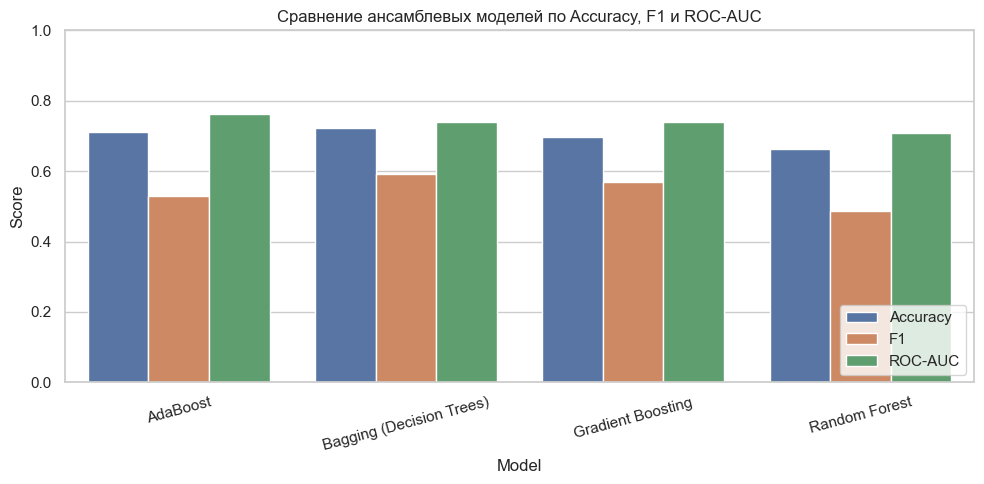

In [7]:
plt.figure(figsize=(10, 5))
plot_df = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'F1', 'ROC-AUC'],
    var_name='Metric',
    value_name='Score',
)
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Сравнение ансамблевых моделей по Accuracy, F1 и ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Матрицы ошибок (confusion matrices)

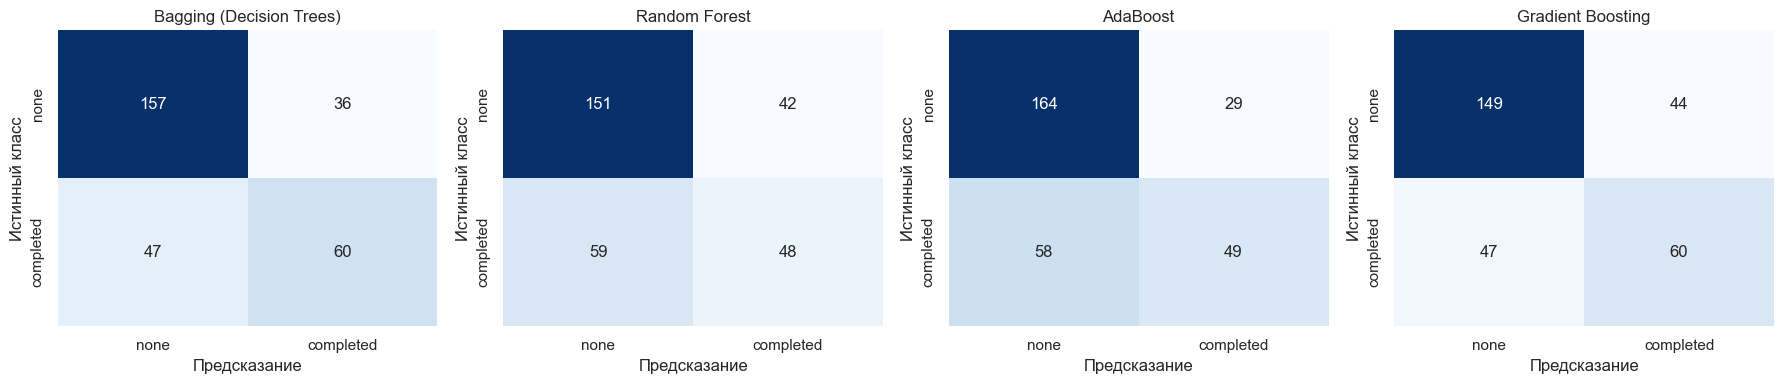

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['none', 'completed'],
        yticklabels=['none', 'completed'],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

## 7. Важность признаков

Для случайного леса и градиентного бустинга выведем топ-15 самых важных признаков.

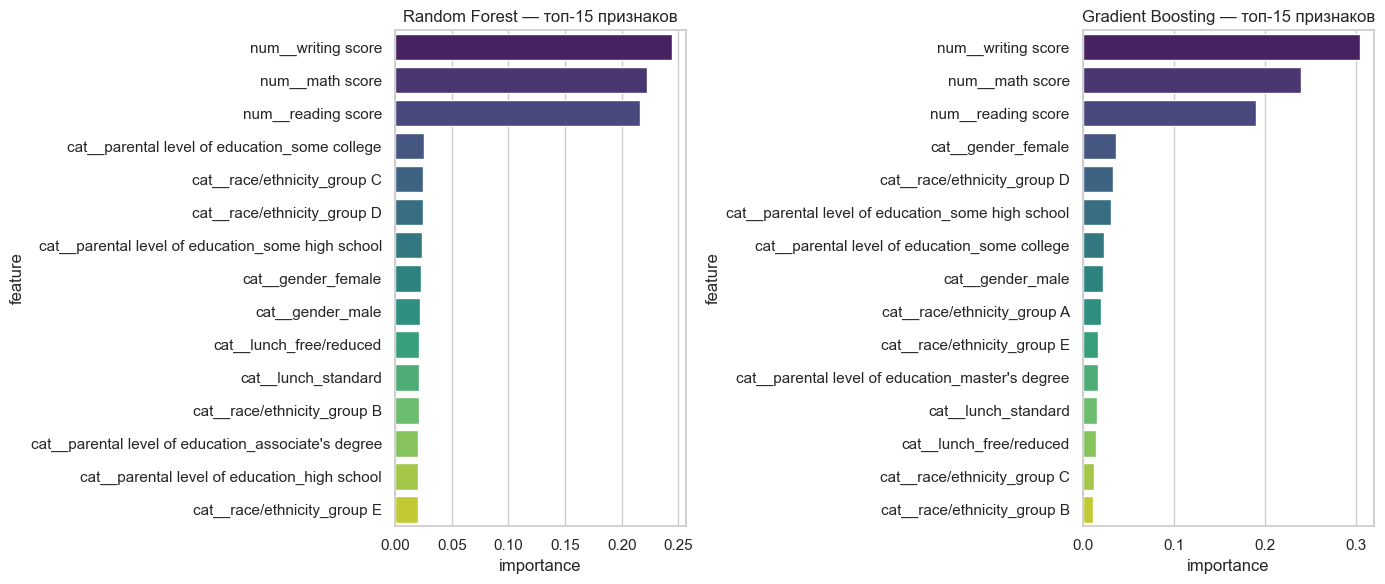

In [9]:
def plot_feature_importance(pipeline, title, ax):
    prep = pipeline.named_steps['prep']
    clf = pipeline.named_steps['clf']
    feature_names = prep.get_feature_names_out()
    importances = clf.feature_importances_
    fi = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(15)
    )
    sns.barplot(data=fi, x='importance', y='feature', hue='feature',
                palette='viridis', legend=False, ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_feature_importance(models['Random Forest'], 'Random Forest — топ-15 признаков', axes[0])
plot_feature_importance(models['Gradient Boosting'], 'Gradient Boosting — топ-15 признаков', axes[1])
plt.tight_layout()
plt.show()

## 8. Вывод

- Подготовлены данные (проверка пропусков, one-hot кодирование категориальных признаков) и выполнено разделение `train_test_split` со стратификацией.
- Обучены четыре ансамблевые модели: `BaggingClassifier`, `RandomForestClassifier` (бэггинг), `AdaBoostClassifier` и `GradientBoostingClassifier` (бустинг).
- Качество моделей оценивалось по метрикам **Accuracy**, **F1-score** и **ROC-AUC**, а также по матрицам ошибок.
- Сводная таблица в разделе 6 и столбчатая диаграмма позволяют напрямую сравнить ансамбли между собой; для лучших моделей построены графики важности признаков.
- Видно, что ансамбли уверенно работают на данной задаче, при этом бустинговые методы (особенно градиентный бустинг) обычно дают более высокую ROC-AUC, чем бэггинговые, за счёт последовательной коррекции ошибок предыдущих базовых моделей.